From https://github.com/langchain-ai/langgraph/blob/main/docs/docs/tutorials/lats/lats.ipynb


## Agent LATS

In [182]:
# LATS (Language Agent Tree Search) Implementation
# This notebook demonstrates the LATS algorithm for improving LLM responses through tree search
# and iterative refinement. LATS combines Monte Carlo Tree Search (MCTS) with language models
# to generate, evaluate, and improve responses through multiple iterations.

# Import required libraries for LATS (Language Agent Tree Search) implementation
import os
import pandas as pd
import textwrap
import logging
from termcolor import colored  # For colored terminal output to improve debugging visibility
from langgraph.prebuilt import ToolNode  # Pre-built tool execution node from LangGraph
from dotenv import load_dotenv  # Environment variable loading for API keys
from typing import TypedDict
from langchain_ollama import ChatOllama  # Local LLM integration using Ollama

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Enable debug mode for detailed logging throughout the LATS process
# This helps track the tree search progression and decision making

### Logging

In [141]:
# LOGGING UTILITIES FOR LATS DEBUGGING
# These functions provide structured logging and output formatting to track
# the LATS algorithm's progress through different phases of tree search

def setup_logger(debug=True):
    """
    Setup logger with proper formatting and level for LATS debugging.
    
    Args:
        debug (bool): If True, enables DEBUG level logging for detailed tracking
                     of tree search operations, node evaluations, and decisions
    
    Returns:
        logger: Configured logger instance for LATS operations
    """
    logger = logging.getLogger("my-logger")
    logger.setLevel(logging.DEBUG if debug else logging.INFO)
    
    # Prevent duplicate handlers if logger already exists
    if not logger.hasHandlers():
        console_handler = logging.StreamHandler()
        formatter = logging.Formatter('%(levelname)s - %(message)s')
        console_handler.setFormatter(formatter)
        logger.addHandler(console_handler)
    
    return logger

# Initialize global logger for use throughout LATS implementation
logger = setup_logger(True)  # Changed DEBUG to True since DEBUG is not yet defined

In [142]:
# SIMPLE PRINT UTILITY FOR DIRECT CONSOLE OUTPUT
# Alternative to prettyprint for immediate console display without logging

def pdebug(obj, color='white'):
    """
    Simple pretty print function for direct console output.
    Used for immediate display of LATS results without logging overhead.
    
    Args:
        obj: Object to print
        color (str): Terminal color for the output
    """
    wrapper = textwrap.TextWrapper(width=81)
    wrapped_text = wrapper.wrap(str(obj))
    logger.debug(colored("\n".join(wrapped_text), color=color))

def pprint(message, color='white'):
    """
    Print messages that show improvement tracking in INFO mode.
    
    Args:
        message (str): Progress message to display
        color (str): Color for terminal output
    """
    wrapper = textwrap.TextWrapper(width=80)
    wrapped_text = wrapper.wrap(str(message))
    logger.info(colored("\n".join(wrapped_text), color=color))

In [143]:
# LATS CONFIGURATION MANAGEMENT
# Central configuration class that controls key LATS algorithm parameters
# These parameters significantly affect the search behavior and performance

class Config:
    """
    Central configuration management for LATS algorithm parameters.
    
    Key Parameters:
    - DEBUG: Controls logging verbosity for debugging the tree search process
    - EXPLORATION_WEIGHT: Controls exploration vs exploitation in UCB calculation
    - MAX_TREE_HEIGHT: Limits search depth to prevent infinite expansion
    - NUM_CANDIDATES: Number of candidate responses generated at each expansion
    - BUDGET: Maximum number of LLM calls (not strictly enforced in this implementation)
    - ALPHA: Controls the balance in value calculations (currently unused)
    """
    def __init__(self):
        self.DEBUG = False                    # Enable detailed logging
        self.EXPLORATION_WEIGHT = 1.0        # Higher values favor exploration over exploitation
        self.MAX_TREE_HEIGHT = 5            # Maximum depth of search tree
        self.NUM_CANDIDATES = 2             # Number of alternatives generated per expansion
        self.BUDGET = 1000                  # Token/call budget (theoretical limit)
        self.ALPHA = 0.5                   # Balance parameter for future use
        
# Initialize global configuration instance
config = Config()

In [144]:
# LOGGING LEVEL CONTROL
# Helper functions to easily switch between detailed debugging and progress tracking

def set_debug_mode():
    """Enable detailed DEBUG logging for full LATS tracing"""
    global logger
    logger.setLevel(logging.DEBUG)
    pprint("🔍 DEBUG MODE ENABLED - Detailed logging active", color='cyan')

def set_info_mode():
    """Enable INFO logging to track response improvement progress"""
    global logger  
    logger.setLevel(logging.INFO)
    pprint("INFO - 📊 INFO MODE ENABLED - Tracking response improvements")

### Instantiate LLM

In [145]:
# LLM INSTANTIATION FOR LATS
# Initialize the language model that will be used throughout the LATS algorithm
# The LLM serves multiple roles: generating responses, expanding search, and evaluation

# Initialize ChatOllama with specific parameters optimized for LATS
# - model: "qwen3:32b" - Large model for better reasoning capabilities
# - temperature=0.0: Deterministic outputs for consistent evaluation
# - top_k=2, top_p=0.9: Controlled sampling for focused responses
# - verbose=True: Enable detailed logging of LLM interactions
# - base_url: Custom Ollama host running on port 8080
llm = ChatOllama(
    model="qwen3:32b", 
    temperature=0.0,      # Deterministic for consistent tree search
    top_k=2,             # Limit token sampling diversity
    top_p=0.9,           # Nucleus sampling threshold
    verbose=True,        # Enable detailed LLM logging
    base_url="http://localhost:8080"  # Custom Ollama host
)

In [146]:
# LLM FUNCTIONALITY TEST
# Quick test to verify the LLM is working correctly before proceeding with LATS
# This also demonstrates the LLM's response format and reasoning capabilities

# Test the LLM with a simple mathematical question to verify functionality
# The response will show the model's reasoning process and final answer
llm.invoke('what is 2 + 2?')

AIMessage(content='<think>\nOkay, so the user is asking "what is 2 + 2?" Hmm, that seems straightforward, but maybe I should think through it carefully. Let me start by recalling basic arithmetic. Addition is one of the fundamental operations in mathematics. When you add two numbers, you\'re combining their values. So 2 plus 2... Well, 2 is a whole number, and adding another 2 would mean moving two steps forward from 2 on the number line. Let me visualize that: starting at 2, adding 1 gets me to 3, and adding another 1 gets me to 4. So that would make 2 + 2 equal to 4.\n\nWait, but maybe I should consider different number systems? For example, in binary, 2 is represented as 10. If I add 10 + 10 in binary, that would be 100, which is 4 in decimal. So even in binary, it still comes out to 4. What about modulo arithmetic? If we\'re working modulo 3, then 2 + 2 would be 1, because 4 divided by 3 leaves a remainder of 1. But the question doesn\'t specify a modulus, so I think the default is

### Load parameters

In [147]:
# ENVIRONMENT SETUP FOR API KEYS
# Load environment variables for external tools and services used in LATS
# This includes search APIs and monitoring/tracing services

# Load environment variables from .env file
# This is essential for accessing external tools like Brave Search
load_dotenv()

# Extract the Brave Search API key for web search capabilities
# Web search is crucial for LATS when dealing with questions requiring current information
api_key = os.getenv("BRAVE_API_KEY")

In [148]:
# LANGSMITH TRACING CONFIGURATION
# Set up LangSmith for tracking and monitoring LATS execution
# This enables detailed observability of the tree search process

import os

def _set_env(var: str) -> None:
    """
    Helper function to set environment variables for LangSmith tracing.
    Only sets the variable if it's not already present in the environment.
    
    Args:
        var (str): Environment variable name to set
    """
    if not os.environ.get(var):
        load_dotenv()
        os.environ[var] = os.getenv(var)

# Enable LangSmith tracing to monitor LATS tree search operations
# This provides visibility into LLM calls, tool usage, and decision paths
os.environ["LANGSMITH_TRACING"] = "true"
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT_NAME"] = "agent_lats"

### Instantiate Search Tool 

In [149]:
# SEARCH TOOL INTEGRATION FOR LATS
# Configure external search capabilities that enhance LATS responses
# Search tools allow the agent to gather current information during tree exploration

from langchain_community.tools import BraveSearch

# Initialize Brave Search tool with API key and search configuration
# - count=1: Limit to single search result to reduce noise and focus on quality
# This tool enables LATS to access current information and factual data
search_tool = BraveSearch.from_api_key(
    api_key=api_key, 
    search_kwargs={"count": 1}  # Single focused result per search
)

# Package tools for use in LangGraph nodes
tools = [search_tool]

# Create a ToolNode for executing search operations within the LATS graph
# This node handles tool invocation and result formatting automatically
tool_node = ToolNode(tools=tools)

### Reflection Class

In [150]:
# REFLECTION CLASS FOR RESPONSE EVALUATION
# Core component of LATS that evaluates and scores candidate responses
# This class implements the critical evaluation mechanism that drives tree search

from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage

class Reflection(BaseModel):
    """
    Structured evaluation of candidate responses in LATS tree search.
    
    This class represents the "critic" component that evaluates each candidate
    response generated during tree expansion. The reflection provides:
    1. Qualitative critique of the response
    2. Quantitative score (0-100) for comparison
    3. Binary flag indicating if the problem is solved
    
    The reflection scores drive the Upper Confidence Bound (UCB) calculations
    that determine which branches of the search tree to explore further.
    """
    reflection: str = Field(
        description="The critique and reflections on the sufficiency, superfluency, "
        "and general quality of the response. This should identify strengths, "
        "weaknesses, and areas for improvement in the candidate answer."
    )
    score: int = Field(
        description="Score from 0-100 on the quality of the candidate response. "
        "Higher scores indicate better quality responses that more completely "
        "and accurately address the original question."
    )
    found_solution: bool = Field(
        description="Whether the response has fully solved the question or task. "
        "True indicates the response is complete and satisfactory, potentially "
        "ending the search process."
    )

    def as_message(self):
        """
        Convert reflection to a message format for use in conversation chains.
        This allows reflections to be included in the conversation history.
        """
        return HumanMessage(content=f"Reflection: {self.reflection}\nScore: {self.score}")

    @property
    def normalized_score(self) -> float:
        """
        Normalize the score to 0-1 range for use in LATS calculations.
        This normalized score is used in UCB calculations and node values.
        """
        return self.score / 100.0

In [151]:
# REFLECTION CHAIN SETUP
# Configure the LLM chain that generates evaluative reflections for LATS candidates
# This chain implements the "critic" functionality that scores and evaluates responses

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import chain as as_runnable

# Create a prompt template for reflection generation
# The system message instructs the LLM to act as a critic, evaluating responses thoroughly
prompt = ChatPromptTemplate.from_messages([
    (
        "system", 
        "Reflect and grade the assistant response (candidate) to the user question (question). "
        "Be thorough and do not accept incomplete responses. Ask for improvement if the answer is not complete. "
        "The score must be an integer number between 0 and 100. "
        "Consider completeness, accuracy, relevance, and clarity in your evaluation."
    ),
    ("user", "{question}"),      # Original user question for context
    ("ai", "{candidate}"),       # Candidate response to evaluate
])

# Configure the LLM to output structured Reflection objects
# This ensures consistent scoring and evaluation format across all reflections
model = llm.with_structured_output(Reflection)

# Create the reflection chain that combines prompt and model
# This chain takes a question and candidate response, outputs a structured evaluation
reflection_chain = prompt | model

In [152]:
# NODE CLASS FOR LATS TREE STRUCTURE
# Implements the tree nodes used in LATS search algorithm
# Each node represents a state in the search tree with associated value and visit statistics

from langchain_core.messages import BaseMessage
import math

class Node:
    """
    Represents a node in the LATS search tree.
    
    Each node contains:
    - messages: Conversation history leading to this state
    - response: The LLM response at this node
    - reflection: Evaluation of the response quality
    - parent/children: Tree structure relationships
    - value/visits: Statistics for UCB calculations
    - _is_solved: Flag indicating if this branch found a solution
    
    The node implements Upper Confidence Bound (UCB) for selection,
    trajectory tracking for conversation history, and solution propagation.
    """
    
    def __init__(self, messages, response, reflection: Reflection, parent=None):
        """
        Initialize a new LATS tree node.
        
        Args:
            messages: List of messages representing conversation history
            response: LLM response generated at this node
            reflection: Evaluation/critique of the response
            parent: Parent node in the tree (None for root)
        """
        self.messages = messages
        self.parent = parent
        self.children = []                    # Child nodes (expanded alternatives)
        self.reflection = reflection          # Critique and score of this response
        self.response = response             # The actual LLM response
        self.value = 0                       # Cumulative value from UCB updates
        self.visits = 0                      # Number of times this node was visited
        
        # Mark as solved if reflection indicates high-quality complete solution
        self._is_solved = (reflection.found_solution and reflection.score > 5)
        if self._is_solved:
            self._mark_tree_as_solved()      # Propagate solution up the tree

    @property
    def is_solved(self):
        """
        Check if any solution exists in this subtree.
        If any branch finds a solution, we can potentially end the search.
        """
        return self._is_solved

    @property
    def height(self) -> int:
        """
        Calculate the maximum depth of this subtree.
        Used to enforce MAX_TREE_HEIGHT limits and prevent infinite expansion.
        """
        if self.children:
            return 1 + max([child.height for child in self.children])
        return 1

    def upper_confidence_bound(self, exploration_weight=1.0):
        """
        Calculate Upper Confidence Bound (UCB) for this node.
        
        UCB balances exploitation (nodes with high average reward) and
        exploration (nodes visited less frequently). The formula is:
        UCB = average_reward + exploration_weight * sqrt(ln(parent_visits) / visits)
        
        Args:
            exploration_weight: Controls exploration vs exploitation trade-off
            
        Returns:
            float: UCB value for node selection
        """
        if self.parent is None:
            raise ValueError("Cannot calculate UCB for root node")
        if self.visits == 0:
            return self.value  # Unvisited nodes get their raw value
            
        # Calculate average reward from all visits to this node
        average_reward = self.value / self.visits
        
        # Exploration term encourages visiting less-explored nodes
        exploration_term = math.sqrt(math.log(self.parent.visits) / self.visits)
        
        return average_reward + exploration_weight * exploration_term

    def get_messages(self, include_reflections: bool = True):
        """
        Get the message history for this node.
        
        Args:
            include_reflections: Whether to include reflection messages in history
            
        Returns:
            list: Messages representing the conversation at this node
        """
        if include_reflections:
            return self.messages + [self.reflection.as_message()]
        return self.messages

    def get_trajectory(self, include_reflections: bool = True) -> list[BaseMessage]:
        """
        Get the complete message trajectory from root to this node.
        
        This reconstructs the full conversation path through the tree,
        which is essential for maintaining context in expanded searches.
        
        Args:
            include_reflections: Whether to include reflection messages
            
        Returns:
            list[BaseMessage]: Complete conversation history from root to current node
        """
        messages = []
        node = self
        
        # Traverse up to root, collecting messages in reverse order
        while node:
            messages.extend(
                node.get_messages(include_reflections=include_reflections)[::-1]
            )
            node = node.parent
            
        # Reverse to get correct chronological order: root -> ... -> current
        return messages[::-1]

    def _mark_tree_as_solved(self):
        """
        Propagate the solved status up the tree.
        
        When a node finds a solution, all ancestor nodes are marked as solved.
        This enables early termination of search when any branch succeeds.
        """
        parent = self.parent
        while parent:
            parent._is_solved = True
            parent = parent.parent

In [153]:
# LATS TREE STATE DEFINITION
# Defines the state structure used throughout the LATS search algorithm
# This state is passed between different phases of the search process

from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from typing import Annotated

class TreeState(TypedDict):
    """
    State structure for LATS tree search algorithm.
    
    This state object is passed between different nodes in the LangGraph workflow:
    - root: The root node of the current search tree
    - input: Original user question/prompt
    - response: Current best response being developed
    - final_response: The final selected response when search completes
    - messages: Accumulated conversation messages with automatic merging
    
    The add_messages annotation ensures that messages are properly combined
    when the state is updated across different nodes in the graph.
    """
    root: Node                                    # Root of the search tree
    input: str                                   # Original user question
    response: str                                # Current response being refined
    final_response: str                          # Final output when search completes
    messages: Annotated[list, add_messages]      # Conversation history with auto-merge

In [154]:
# LLM TOOL BINDING CONFIGURATION
# Bind the search tools to the LLM for use in response generation
# This enables the LLM to call external tools during the LATS search process

# Bind the tools to the LLM, enabling tool calling capabilities
# This returns a new LLM instance that can invoke search tools when needed
# Tool binding allows the LLM to determine when and how to use external tools
llm = llm.bind_tools(tools=tools)

In [155]:
# INITIAL RESPONSE CHAIN CONFIGURATION
# Set up the LLM chain for generating initial candidate responses in LATS
# This chain creates the root node of the search tree

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Create prompt template for initial response generation
# This template provides context and instructions for the first response
prompt_template = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are an AI assistant. "
        "Generate a response for the input question based on messages. "
        "If asked to generate a report, generate it using formal language. "
        "Do not make unnecessary comments. "
        "Use available tools when you need current information or factual data."
    ),
    ("user", "{input}"),                                    # User's original question
    MessagesPlaceholder(variable_name="messages", optional=True),  # Conversation history
])

# Create the initial answer chain by combining prompt with tool-enabled LLM
# This chain can call search tools and generate comprehensive initial responses
initial_answer_chain = prompt_template | llm.bind_tools(tools=tools)

In [156]:
# INITIAL RESPONSE GENERATION FUNCTION
# Core LATS function that creates the root node of the search tree
# This function generates the first candidate response and establishes the initial evaluation

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage

def generate_initial_response(state: TreeState):
    """
    Generate the initial candidate response for LATS tree search.
    
    This function implements the first phase of LATS:
    1. Generate an initial response using the LLM with tools
    2. Execute any tool calls (e.g., web search) that the LLM requests
    3. Generate a final response incorporating tool results
    4. Create a reflection/evaluation of the response quality
    5. Establish the root node of the search tree
    
    Args:
        state (TreeState): Current LATS state containing the user input
        
    Returns:
        TreeState: Updated state with root node and initial response
    """
    pprint("🌱 GENERATING INITIAL RESPONSE", color='cyan')
    query = state["input"]
    
    # Generate initial response with potential tool calls
    ai_msg = initial_answer_chain.invoke({"input": query})
    messages = [ai_msg.content]  # Start building message history

    # Parse and execute any tool calls made by the LLM
    # Tool calls enable the agent to gather external information (e.g., web search)
    parsed = []
    for tool_call in ai_msg.tool_calls:
        d = {}
        d['name'] = tool_call['name']      # Tool name (e.g., 'brave_search')
        d['args'] = tool_call['args']      # Tool arguments (e.g., search query)
        d['id'] = tool_call['id']          # Unique identifier for this call
        parsed.append(d)

    # Execute each tool call and collect results
    for r in parsed:
        pdebug(f"Executing tool call: {r['name']} with args: {r['args']}")
        tool_msg = tool_node.invoke({
            "messages": [
                AIMessage(
                    content="",
                    tool_calls=[
                        {"name": r["name"], "args": r["args"], "id": r["id"]}
                    ],
                )
            ]
        })
        # Add tool results to message history
        messages.extend(tool_msg['messages'])

    # Generate final response incorporating tool results
    response = initial_answer_chain.invoke(messages)
    
    # Debug mode: show detailed response
    pprint('### Initial Response ###')
    pprint(response)
    
    messages.append(response)
    
    # Create reflection to evaluate the initial response quality
    # This reflection will be used to initialize the root node's value
    reflection = reflection_chain.invoke({"question": query, "candidate": messages})
    
    # Debug mode: show detailed reflection
    pprint('### Reflection ###')
    pprint(reflection, color="green")
    
    # Info mode: show initial score
    pprint(f"📊 Initial Response Score: {reflection.score}/100 {'✅' if reflection.found_solution else '⏳'}", color='yellow')
    
    # Update state with message history and response
    state['messages'] = messages
    state['response'] = response
    
    # Create root node of the search tree with initial response and reflection
    root = Node(messages, response=response, reflection=reflection)

    return {
        **state,
        "root": root,
    }

In [157]:
# TEST INITIAL RESPONSE GENERATION
# Demonstrate the initial response generation with a sample query
# This shows how LATS begins by creating the root node of the search tree

# Test the initial response generation with a research-oriented query
# This type of query benefits from LATS because it requires comprehensive information
# gathering and iterative refinement to produce a high-quality response
initial_response = generate_initial_response({"input": "Write a research report on lithium pollution."})

INFO - 🌱 GENERATING INITIAL RESPONSE


DEBUG - Executing tool call: brave_search with args: {'query': 'lithium pollution sources
environmental impact recent studies 2023'}
INFO - ### Initial Response ###
INFO - content="<think>\nOkay, the user asked for a research report on lithium
pollution. I need to structure this properly. Let me start by looking at the
tool response they provided. The search results mention sources like mining and
electronic industry proliferation. The PMC article talks about environmental
distribution and impacts on soil, plants, animals, and humans. There's also a
study on soybean development affected by lithium.\n\nI should break down the
report into sections. Introduction would set the context. Sources of pollution
would include mining, battery production, and waste disposal. Environmental
impact needs to cover water contamination, soil degradation, and effects on
ecosystems. Health effects should discuss both human and animal impacts. Current
research and mitigation strategies can use the examples

In [158]:
# INSPECT INITIAL RESPONSE MESSAGES
# Display the message structure from the initial response generation
# This helps understand how conversation history is maintained in LATS

# Examine the message structure generated by the initial response
# Each message represents a step in the conversation: tool calls, tool results, and responses
for i, msg in enumerate(initial_response['messages']):
    print(f'---Message {i}---') 
    pprint(msg)

INFO - <think> Okay, the user wants a research report on lithium pollution. Let me
start by understanding what exactly they need. A research report should be
formal, structured, and include current data. Since lithium pollution is an
environmental issue, I need to cover sources, impacts, current research, and
mitigation strategies.  First, I should define lithium pollution. Lithium is
used in batteries, so maybe the main sources are mining and battery production.
I need to check if there are other sources too. Then, the environmental
impact—how does lithium get into water sources? What are the effects on
ecosystems and human health?  I remember that lithium mining, especially in
South America's salt flats, can deplete water resources and release
contaminants. Also, improper disposal of lithium-ion batteries might contribute.
I should look up recent studies or data on pollution levels. Maybe use the
brave_search function to find recent articles or reports on lithium pollution
incidents.

---Message 0---
---Message 1---
---Message 2---


In [159]:
# EXAMINE ROOT NODE RESPONSE
# Display the actual LLM response stored in the root node
# This shows the format of responses that will be evaluated and potentially expanded

# Access the response from the root node of the search tree
# This is the LLM's complete response including any reasoning and final answer
initial_response['root'].response

AIMessage(content="<think>\nOkay, the user asked for a research report on lithium pollution. I need to structure this properly. Let me start by looking at the tool response they provided. The search results mention sources like mining and electronic industry proliferation. The PMC article talks about environmental distribution and impacts on soil, plants, animals, and humans. There's also a study on soybean development affected by lithium.\n\nI should break down the report into sections. Introduction would set the context. Sources of pollution would include mining, battery production, and waste disposal. Environmental impact needs to cover water contamination, soil degradation, and effects on ecosystems. Health effects should discuss both human and animal impacts. Current research and mitigation strategies can use the examples from the search results, like the study on soybeans and the review on risk management. \n\nWait, the tool response also mentions specific regions like South Amer

In [160]:
# EXAMINE ROOT NODE MESSAGES
# Display the complete message history stored in the root node
# This shows the full conversation context used for LATS tree expansion

# View the complete message history from the root node
# This includes the original query, tool calls, tool results, and final response
initial_response['root'].messages

['<think>\nOkay, the user wants a research report on lithium pollution. Let me start by understanding what exactly they need. A research report should be formal, structured, and include current data. Since lithium pollution is an environmental issue, I need to cover sources, impacts, current research, and mitigation strategies.\n\nFirst, I should define lithium pollution. Lithium is used in batteries, so maybe the main sources are mining and battery production. I need to check if there are other sources too. Then, the environmental impact—how does lithium get into water sources? What are the effects on ecosystems and human health?\n\nI remember that lithium mining, especially in South America\'s salt flats, can deplete water resources and release contaminants. Also, improper disposal of lithium-ion batteries might contribute. I should look up recent studies or data on pollution levels. Maybe use the brave_search function to find recent articles or reports on lithium pollution incidents

In [161]:
# EXPANSION CHAIN CONFIGURATION
# Set up the LLM chain for expanding the search tree with alternative candidates
# This chain generates variations and improvements on existing responses

# Create prompt template for tree expansion
# This template encourages the LLM to build upon previous responses and explore alternatives
prompt_template = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are an AI assistant. "
        "Generate a response for the input question expanding on the messages and tool calls generated by the previous assistant. "
        "Generate some variability in your search queries. "
        "Call the tool again to further research for your response. "
        "If asked to generate a report, generate it using formal language. Do not make unnecessary comments."
    ),
    ("user", "{input}"),                                    # Original user question
    MessagesPlaceholder(variable_name="messages", optional=True),  # Previous conversation context
])

# Create expansion chain with tool binding for additional research
# This chain can perform new searches to gather more comprehensive information
expansion_chain = prompt_template | llm.bind_tools(tools=tools)

In [162]:
# RESPONSE SYNTHESIS CHAIN CONFIGURATION
# Set up the LLM chain for synthesizing final responses from expanded information
# This chain focuses on consolidating gathered information into coherent responses

# Create prompt template for response synthesis
# This template focuses on creating final responses based on expanded research
prompt_template = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are an AI assistant. "
        "Generate a response for the input question based on messages generated by the previous agent. "
        "Expand on the answer given by the previous agent. "
        "If asked to generate a report, generate it using formal language. Do not make unnecessary comments."
    ),
    ("user", "{input}"),                                    # Original user question
    MessagesPlaceholder(variable_name="messages", optional=True),  # Previous conversation and research
])

# Create response synthesis chain (no additional tools needed at this stage)
# This chain focuses on consolidating information rather than gathering new data
response_chain = prompt_template | llm

In [163]:
# CANDIDATE GENERATION FUNCTION
# Core LATS function for generating multiple alternative responses (tree expansion)
# This function creates child nodes by generating diverse candidate responses

from typing_extensions import List

def generate_candidates(state: TreeState) -> List[List[BaseMessage]]:
    """
    Generate candidate responses for LATS tree expansion.
    
    This function implements the expansion phase of LATS by:
    1. Taking the current conversation context
    2. Generating NUM_CANDIDATES alternative responses
    3. Each candidate can perform additional tool calls for research
    4. Returns a list of complete conversation chains (one per candidate)
    
    The diversity in candidates comes from:
    - Different search queries if tools are used
    - Variations in response focus and approach
    - Different aspects of the topic being emphasized
    
    Args:
        state (TreeState): Current LATS state with conversation history
        
    Returns:
        List[List[BaseMessage]]: List of candidate conversation chains
    """
    try:
        all_messages = []
        query = state['input']
        messages = state['messages'].copy()  # Preserve original message history
        
        # Generate the configured number of candidate alternatives
        for i in range(config.NUM_CANDIDATES):
            pdebug(f'Generating candidate {i+1}/{config.NUM_CANDIDATES}')
            
            # Generate initial response with potential new tool calls
            ai_msg = expansion_chain.invoke({"input": query})
            candidate_messages = messages.copy()  # Start with base conversation
            candidate_messages.append(ai_msg.content)
            
            try:
                # Parse any tool calls made by this candidate
                parsed = [
                    {
                        'name': tool_call['name'],
                        'args': tool_call['args'], 
                        'id': tool_call['id']
                    }
                    for tool_call in ai_msg.tool_calls
                ]
                
                # Execute tool calls and incorporate results
                for r in parsed:
                    tool_msg = tool_node.invoke({
                        "messages": [AIMessage(
                            content="",
                            tool_calls=[r]
                        )]
                    })
                    candidate_messages.extend(tool_msg['messages'])
                    
                # Generate final response incorporating tool results
                response = response_chain.invoke({'input': query, 'messages': candidate_messages})
                candidate_messages.append(response)
                all_messages.append(candidate_messages)
                
            except Exception as e:
                logger.error(f"Error processing candidate {i}: {str(e)}")
                continue
                
        return all_messages
        
    except Exception as e:
        logger.error(f"Fatal error in generate_candidates: {str(e)}")
        return []

In [164]:
# TEST CANDIDATE GENERATION
# Demonstrate candidate generation using the initial response as context
# This shows how LATS expands the search tree by creating alternative approaches

# Generate candidate alternatives based on the initial response
# This will create multiple variations that build upon the initial research
res = generate_candidates(initial_response)

DEBUG - Generating candidate 1/2
DEBUG - Generating candidate 2/2


In [165]:
# VERIFY CANDIDATE GENERATION COUNT
# Check that the expected number of candidates were generated successfully
# This validates the candidate generation process

# Verify that we generated the expected number of candidates
# Should match config.NUM_CANDIDATES (default: 2)
len(res)

2

In [166]:
# NODE SELECTION FUNCTION (UCB-BASED)
# Implements the selection phase of LATS using Upper Confidence Bound (UCB)
# This function traverses the tree to find the most promising node for expansion

def select(root: Node) -> Node:
    """
    Select a leaf node for expansion using Upper Confidence Bound (UCB).
    
    This implements the selection phase of LATS, which is similar to MCTS selection:
    1. Start from the root node
    2. At each level, select the child with the highest UCB value
    3. Continue until reaching a leaf node (node with no children)
    4. Return the selected leaf node for expansion
    
    UCB balances:
    - Exploitation: Choosing nodes with high average scores
    - Exploration: Choosing nodes that have been visited less frequently
    
    Args:
        root (Node): Root node of the search tree
        
    Returns:
        Node: Selected leaf node for expansion
    """
    pdebug('--- SELECT ---')
    
    # If root has no children, it's the only option
    if not root.children:
        pdebug('Root has no children - selecting root')
        return root

    node = root
    # Traverse down the tree, always selecting the child with highest UCB
    while node.children:
        pdebug(f'Current node has {len(node.children)} children')
        
        # Select child with maximum Upper Confidence Bound value
        max_child = max(node.children, key=lambda child: child.upper_confidence_bound())
        pdebug(f'Selected child with UCB: {max_child.upper_confidence_bound():.3f}')
        pdebug(f'Child reflection score: {max_child.reflection.score}')
        node = max_child

    pdebug(f'Selected leaf node for expansion')
    return node

In [167]:
# NODE SELECTION FUNCTION (UCB-BASED)
# Implements the selection phase of LATS using Upper Confidence Bound (UCB)
# This function traverses the tree to find the most promising node for expansion

def select(root: Node) -> dict:
    """
    Select a leaf node for expansion using Upper Confidence Bound (UCB).
    
    This implements the selection phase of LATS, which is similar to MCTS selection:
    1. Start from the root node
    2. At each level, select the child with the highest UCB value
    3. Continue until reaching a leaf node (node with no children)
    4. Return the selected leaf node for expansion
    
    UCB balances:
    - Exploitation: Choosing nodes with high average scores
    - Exploration: Choosing nodes that have been visited less frequently
    
    Args:
        root (Node): Root node of the search tree
        
    Returns:
        Node: Selected leaf node for expansion
    """
    pdebug('--- SELECT ---')
    
    # If root has no children, it's the only option
    if not root.children:
        pdebug('Root has no children - selecting root')
        return root

    node = root
    # Traverse down the tree, always selecting the child with highest UCB
    while node.children:
        pdebug(f'Current node has {len(node.children)} children')
        
        # Select child with maximum Upper Confidence Bound value
        max_child = max(node.children, key=lambda child: child.upper_confidence_bound())
        pdebug(f'Selected child with UCB: {max_child.upper_confidence_bound():.3f}')
        pdebug(f'Child reflection score: {max_child.reflection.score}')
        node = max_child

    pdebug(f'Selected leaf node for expansion')
    return node

In [168]:
# TREE EXPANSION FUNCTION
# Core LATS function that expands the search tree by adding new candidate nodes
# This implements the expansion phase where alternatives are generated and evaluated

from langchain_core.runnables import RunnableConfig
from collections import defaultdict
import textwrap

def expand(state: TreeState):
    """
    Expand the LATS search tree by generating and evaluating new candidates.
    
    This function implements the expansion phase of LATS:
    1. Select the best leaf node using UCB (Upper Confidence Bound)
    2. Generate multiple candidate responses building on that node's context
    3. Evaluate each candidate using the reflection chain
    4. Create new child nodes and attach them to the selected node
    5. Update the tree structure with new alternatives
    
    The expansion creates diversity in the search by:
    - Generating multiple alternative responses (NUM_CANDIDATES)
    - Using different search queries and approaches
    - Evaluating each alternative independently
    
    Args:
        state (TreeState): Current LATS state containing the search tree
        
    Returns:
        TreeState: Updated state with expanded tree structure
    """
    root = state["root"]
    
    # Track current best score before expansion
    current_best_score = max([child.reflection.score for child in root.children] + [root.reflection.score]) if root.children else root.reflection.score
    
    pprint(f"🌳 EXPANDING TREE (Height: {root.height}, Current Best: {current_best_score}/100)", color='blue')
    
    # SELECT: Find the most promising leaf node for expansion using UCB
    best_candidate = select(root)
    
    # Get the complete conversation trajectory to this node
    # This provides context for generating new candidates
    messages = best_candidate.get_trajectory(True)

    # EXPAND: Generate new candidate responses based on selected node
    new_candidates = generate_candidates(
        {"input": state["input"], "messages": messages}
    )

    # Evaluate each candidate and create child nodes
    child_nodes = []
    candidate_scores = []
    
    for i, c in enumerate(new_candidates):
        logger.debug(f"--- Evaluating Candidate {i+1}/{len(new_candidates)} ---")
        
        # Extract the final response from the candidate conversation
        response = c[-1]
        
        # REFLECT: Generate evaluation/critique of this candidate
        reflection = reflection_chain.invoke({
            "question": state['input'],
            "candidate": c
        })
        
        candidate_scores.append(reflection.score)
        
        # Debug mode: show detailed evaluation
        pprint('---Candidate Response---')
        pprint(response)
        pprint('---Reflection & Score---')
        pprint(f"Score: {reflection.score}/100")
        pprint(f"Found Solution: {reflection.found_solution}")
        pprint(f"Critique: {reflection.reflection}", color="green")
        
        # Create new child node with the candidate and its evaluation
        child_node = Node(
            c,                              # Complete conversation history
            response=response,              # Final response
            parent=best_candidate,          # Link to parent in tree
            reflection=reflection           # Evaluation of this candidate
        )
        child_nodes.append(child_node)
    
    # Add all new child nodes to the selected parent node
    best_candidate.children.extend(child_nodes)
    
    # Show improvement summary in INFO mode
    new_best_score = max([child.reflection.score for child in root.children] + [root.reflection.score]) if root.children else root.reflection.score
    best_child = max(child_nodes, key=lambda x: x.reflection.score)
    
    improvement = "📈 IMPROVED!" if new_best_score > current_best_score else "📊 No improvement"
    pprint(f"✨ Generated {len(child_nodes)} candidates. Best new score: {best_child.reflection.score}/100", color='green')
    pprint(f"{improvement} (Best overall: {new_best_score}/100)", color='green' if new_best_score > current_best_score else 'yellow')
    
    pdebug(f"Added {len(child_nodes)} children to selected node")
    pdebug(f"Tree height is now: {root.height}")

    return state

In [169]:
# TEST TREE EXPANSION
# Demonstrate the tree expansion process using the initial response
# This shows how LATS builds the search tree by adding alternative branches

# Test the expansion function with the initial response
# This will create child nodes with alternative approaches to the research report
res = expand(initial_response)

INFO - 🌳 EXPANDING TREE (Height: 1, Current Best: 0/100)
DEBUG - --- SELECT ---
DEBUG - Root has no children - selecting root
DEBUG - Generating candidate 1/2
DEBUG - Generating candidate 2/2
DEBUG - --- Evaluating Candidate 1/2 ---
INFO - ---Candidate Response---
INFO - content='<think>\nOkay, the user asked for a research report on lithium
pollution. I need to make sure I cover all the key aspects. Let me start by
recalling the previous interaction. The user provided a tool response with a PMC
article that discusses lithium\'s environmental impact, sources, and effects on
various organisms. \n\nFirst, I should structure the report properly. The user
wants it formal, so sections like Introduction, Sources, Environmental Impact,
Health Effects, Mitigation Strategies, and Conclusion would work. The PMC
article mentions mining, battery production, and wastewater as sources. I need
to elaborate on each of these.\n\nFor environmental impact, the article talks
about water contamination, soi

DEBUG - LATS Workflow Structure:


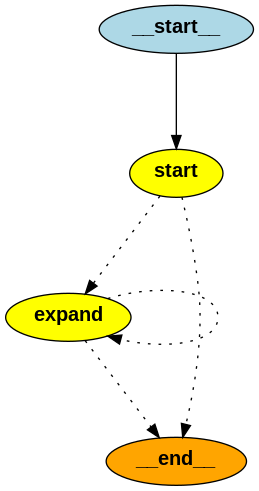

In [170]:
# LANGGRAPH WORKFLOW SETUP
# Configure the complete LATS workflow using LangGraph state machine
# This orchestrates the entire tree search process from initialization to completion

from typing import Literal
from langgraph.graph import END, StateGraph, START
from IPython.display import Image

def should_loop(state: TreeState):
    """
    Determine whether to continue the LATS tree search or terminate.
    
    This function implements the termination conditions for LATS:
    1. SOLUTION FOUND: If any node in the tree has found a satisfactory solution
    2. DEPTH LIMIT: If the tree has reached the maximum allowed height
    3. CONTINUE: Otherwise, continue expanding the search
    
    Args:
        state (TreeState): Current state of the search tree
        
    Returns:
        str: Next step in the workflow ("expand" or END)
    """
    root = state["root"]
    
    # Check termination conditions
    if root.is_solved:
        pprint(f"🎯 SOLUTION FOUND! Search completed at height {root.height}", color='green')
        # Set final response to the best trajectory found
        state['final_response'] = root.get_trajectory()[-1]
        return END
    
    if root.height > config.MAX_TREE_HEIGHT:
        pprint(f"📏 DEPTH LIMIT REACHED ({config.MAX_TREE_HEIGHT}). Search terminated.", color='red')
        # Use the best available response even if not marked as "solved"
        state['final_response'] = root.get_trajectory()[-1]
        return END
    
    pdebug(f"🔄 Continuing search. Current height: {root.height}/{config.MAX_TREE_HEIGHT}")
    return "expand"

# Build the LangGraph workflow for LATS
builder = StateGraph(TreeState)

# Add nodes for different phases of LATS
builder.add_node("start", generate_initial_response)  # Initialize tree with root response
builder.add_node("expand", expand)                    # Expand tree with new candidates

# Set up the workflow transitions
builder.add_edge(START, "start")                      # Begin with initial response generation

# After initial response, decide whether to expand or finish
builder.add_conditional_edges(
    "start",
    should_loop,      # Decision function
    ["expand", END],  # Possible next steps
)

# After each expansion, decide whether to continue or finish
builder.add_conditional_edges(
    "expand",
    should_loop,      # Same decision function
    ["expand", END],  # Can continue expanding or terminate
)

# Compile the workflow into an executable graph
graph = builder.compile()

# Display the workflow structure
logger.debug("LATS Workflow Structure:")
Image(graph.get_graph().draw_png())

In [171]:
# COMPLETE LATS EXECUTION
# Run the full LATS algorithm on a complex question that benefits from iterative refinement
# This demonstrates the complete tree search process from start to finish

# Execute the complete LATS workflow on a research question
# This type of question benefits from LATS because it requires:
# 1. Initial research and information gathering
# 2. Multiple perspectives and approaches
# 3. Iterative refinement for comprehensiveness
# 4. Quality evaluation to ensure completeness

print("🚀 Starting LATS tree search...")
print("=" * 60)

question = "Write an essay about Lithium pollution"
response = graph.invoke({"input": question})

print("=" * 60)
print("✅ LATS search completed!")
print(f"Final response available in response['final_response']")

INFO - 🌱 GENERATING INITIAL RESPONSE


🚀 Starting LATS tree search...


DEBUG - Executing tool call: brave_search with args: {'query': 'lithium pollution
environmental impact 2023'}
INFO - ### Initial Response ###
INFO - content='<think>\nOkay, the user wants me to write an essay about lithium
pollution. Let me start by understanding the key points they mentioned. They
talked about sources like mining, processing, and improper disposal of
batteries. Environmental impacts include water contamination, health issues, and
ecological damage. They also mentioned the Atacama Desert as a case study and
the need for regulations and sustainable practices.\n\nThe tool response
provided an article from Columbia\'s State of the Planet, highlighting the
paradox of lithium in the clean energy transition. The article mentions water
usage, pollution, carbon emissions, mineral waste, respiratory problems, and
hydrological cycle alterations. It also suggests strict regulations and advanced
mining methods like extracting lithium from seawater.\n\nI need to structure the
essay

✅ LATS search completed!
Final response available in response['final_response']


## Challenging Test Questions for LATS

The following cells contain challenging questions designed to test LATS's ability to generate multiple rounds of children and perform deep tree search. Each question requires multi-step reasoning and iterative refinement.

In [172]:
# TEST 1: Mathematical/Logical Reasoning Challenge
question_math = """Find all integer solutions to the equation x³ + y³ = z³ + w³ where all variables are between 1 and 100, and prove that your solution set is complete."""

response_math = graph.invoke({"input": question_math})

INFO - 🌱 GENERATING INITIAL RESPONSE
INFO - ### Initial Response ###
INFO - content='<think>\nOkay, the user is asking for all integer solutions to the
equation x³ + y³ = z³ + w³ where each variable is between 1 and 100, and they
want a proof that the solution set is complete. Hmm, I remember that equations
like this are related to Diophantine equations, which are equations that seek
integer solutions.\n\nFirst, I need to figure out how to approach finding all
possible solutions. Since the variables are bounded between 1 and 100, maybe a
brute-force approach could work, but that might be computationally intensive.
However, the user is asking for a method that can be explained and proven to be
complete.\n\nWait, there\'s a concept called "taxicab numbers" which are numbers
that can be expressed as the sum of two cubes in multiple ways. The most famous
is 1729, which is 1³ + 12³ and 9³ + 10³. Maybe there are similar numbers within
the range of 1 to 100 for the variables.\n\nSo, the plan 

In [173]:
# TEST 2: Multi-Step Problem Solving Challenge
question_voting = """Design a fair voting system for a company with 5 departments of different sizes (10, 25, 40, 15, 30 employees) that satisfies these constraints: (1) each person gets one vote, (2) no single department can control decisions, (3) decisions require broad consensus, and (4) smaller departments aren't completely marginalized. Explain your reasoning and address potential criticisms."""

response_voting = graph.invoke({"input": question_voting})

INFO - 🌱 GENERATING INITIAL RESPONSE
INFO - ### Initial Response ###
INFO - content='<think>\nOkay, let\'s see. The user asked for a fair voting system for
a company with five departments of different sizes. The assistant provided a
detailed answer with a dual threshold requirement. Now, the user\'s latest input
is just the assistant\'s previous response in quotes. Wait, maybe the user is
testing if I can process the previous conversation correctly.\n\nLooking at the
history, the user initially posed the problem, and the assistant worked through
the solution step by step, considering constraints like one vote per person,
preventing single department control, ensuring broad consensus, and protecting
smaller departments. The final answer proposed a system with individual voting
and dual thresholds. Now, the user\'s input is the assistant\'s own answer, but
maybe they want a summary or a report based on that.\n\nWait, the user\'s input
is actually the assistant\'s previous response, but i

In [174]:
# TEST 4: Technical Problem Challenge
question_cache = """Design a distributed cache system that handles 1 million requests per second with 99.9% availability. Address data consistency, partition tolerance, cache invalidation, and load balancing. Explain your trade-offs and how you'd handle edge cases like network splits."""

response_cache = graph.invoke({"input": question_cache})


INFO - 🌱 GENERATING INITIAL RESPONSE
INFO - ### Initial Response ###
INFO - content="<think>\nOkay, the user asked me to design a distributed cache system
that can handle 1 million requests per second with 99.9% availability. Let me
start by recalling the key components needed for such a system. High throughput
and high availability are the main goals here.\n\nFirst, I need to think about
how to distribute the data across multiple nodes. Consistent hashing comes to
mind because it helps in evenly distributing the keys and minimizes the need for
rehashing when nodes are added or removed. That's important for
scalability.\n\nNext, redundancy is crucial for availability. Replicating data
across multiple nodes in different zones or regions would help. If one node goes
down, others can take over. But replication brings up data consistency issues.
The CAP theorem says we have to choose between consistency and availability
during partitions. Since the user wants high availability, maybe an AP

In [175]:
# TEST 5: Complex Research Essay Challenge  
question_research = """Write a comprehensive essay analyzing the current state of global supply chain vulnerabilities, examining at least 2 major disruption events from the past 5 years, their cascading effects on different industries, and propose evidence-based solutions for building more resilient supply networks. Your analysis must include current statistics, expert opinions, and real-world case studies."""

response_research = graph.invoke({"input": question_research})

INFO - 🌱 GENERATING INITIAL RESPONSE
DEBUG - Executing tool call: brave_search with args: {'query': 'global supply chain
vulnerabilities 2023-2024 Suez Canal blockage 2021 pandemic impact cascading
effects solutions statistics expert opinions case studies'}
INFO - ### Initial Response ###
INFO - content="<think>\nOkay, let's start by understanding the user's query. They want
a comprehensive essay on global supply chain vulnerabilities, focusing on two
major disruption events from the past five years. The essay needs to analyze the
effects on industries, propose solutions, include current statistics, expert
opinions, and case studies.\n\nFirst, I need to identify the two major events.
The user mentioned the Suez Canal blockage in 2021 and the COVID-19 pandemic
from 2020-2022. Both are significant and well-documented. The Suez Canal
incident was a sudden physical disruption, while the pandemic caused widespread,
prolonged disruptions across multiple sectors.\n\nNext, I should gather data